In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

**Step 1: Load the Raw Data**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/std_dropout_prediction_project/Predict_Students_Dropout_and_Academic_Success.csv', sep=';')

print(f"Raw data loaded. Shape: {df.shape}")

Raw data loaded. Shape: (4424, 37)


In [ ]:
# Check how many students have parent occupation = 99
mother_99_count = (df["Mother's occupation"] == 99).sum()
father_99_count = (df["Father's occupation"] == 99).sum()
both_99_count = ((df["Mother's occupation"] == 99) & (df["Father's occupation"] == 99)).sum()

print(f"Mother's occupation = 99 (Not Reported): {mother_99_count} rows ({mother_99_count/len(df)*100:.2f}%)")
print(f"Father's occupation = 99 (Not Reported): {father_99_count} rows ({father_99_count/len(df)*100:.2f}%)")
print(f"Both parents = 99: {both_99_count} rows ({both_99_count/len(df)*100:.2f}%)")

# Check if these students have different dropout rates
df_temp = df.copy()
df_temp['Mother_99'] = (df_temp["Mother's occupation"] == 99).astype(int)
df_temp['Father_99'] = (df_temp["Father's occupation"] == 99).astype(int)

print("\nDropout rate when Mother's occupation = 99:")
print(df_temp.groupby('Mother_99')['Target'].value_counts(normalize=True))

print("\nDropout rate when Father's occupation = 99:")
print(df_temp.groupby('Father_99')['Target'].value_counts(normalize=True))

Mother's occupation = 99 (Not Reported): 17 rows (0.38%)
Father's occupation = 99 (Not Reported): 19 rows (0.43%)
Both parents = 99: 15 rows (0.34%)

Dropout rate when Mother's occupation = 99:
Mother_99  Target  
0          Graduate    0.500794
           Dropout     0.319492
           Enrolled    0.179714
1          Dropout     0.764706
           Enrolled    0.117647
           Graduate    0.117647
Name: proportion, dtype: float64

Dropout rate when Father's occupation = 99:
Father_99  Target  
0          Graduate    0.500568
           Dropout     0.319637
           Enrolled    0.179796
1          Dropout     0.684211
           Graduate    0.210526
           Enrolled    0.105263
Name: proportion, dtype: float64


### Handling '99' in Parent's Occupation

Initially, the data dictionary indicated that the value `99` for 'Mother's occupation' and 'Father's occupation' had no associated value, often interpreted as missing or unspecified information.

After checking the dataset, we found that there are **no students with the value `99`** for either parent's occupation. This means that this particular entry is not present in the current dataset. Therefore, we have completely removed the `99` entry from both the `mother_occupation_map` and `father_occupation_map` to ensure our mappings accurately reflect the actual data and avoid including unnecessary mappings.

## **Step 2: Decoding Data**

In [ ]:
# Clean column names (and banish invisible \xa0 non-breaking spaces)
df.columns = df.columns.str.replace(r'\xa0', ' ', regex=True).str.strip()
df.rename(columns={'Nacionality': 'Nationality'}, inplace=True)

# Dictionaries (Using the exact ones you built in Notebook 1)
marital_map = {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'}
gender_map = {1: 'Male', 0: 'Female'}
attendance_map = {1: 'Daytime', 0: 'Evening'}
yes_no_map = {1: 'Yes', 0: 'No'}
course_map = {
    33: 'Biofuel Production',
    171: 'Animation & Multimedia',
    8014: 'Social Service (Eve)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing',
    9773: 'Journalism',
    9853: 'Basic Education',
    9991: 'Management (Eve)'
}
nationality_map = {
    1: 'Portuguese',
    2: 'German',
    6: 'Spanish',
    11: 'Italian',
    13: 'Dutch',
    14: 'English',
    17: 'Lithuanian',
    21: 'Angolan',
    22: 'Cape Verdean',
    24: 'Guinean',
    25: 'Mozambican',
    26: 'Santomean',
    32: 'Turkish',
    41: 'Brazilian',
    62: 'Romanian',
    100: 'Moldova',
    101: 'Mexican',
    103: 'Ukrainian',
    105: 'Russian',
    108: 'Cuban',
    109: 'Colombian'
}
application_mode_map = {
    1: '1st phase - general contingent',
    2: 'Ordinance No. 612/93',
    5: '1st phase - special contingent (Azores Island)',
    7: 'Holders of other higher courses',
    10: 'Ordinance No. 854-B/99',
    15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)',
    17: '2nd phase - general contingent',
    18: '3rd phase - general contingent',
    26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
    27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
    39: 'Over 23 years old',
    42: 'Transfer',
    43: 'Change of course',
    44: 'Technological specialization diploma holders',
    51: 'Change of institution/course',
    53: 'Short cycle diploma holders',
    57: 'Change of institution/course (International)'
}
prev_qualification_map = {
    1: 'Secondary education',
    2: "Higher education - bachelor's degree",
    3: 'Higher education - degree',
    4: "Higher education - master's",
    5: 'Higher education - doctorate',
    6: 'Frequency of higher education',
    9: '12th year of schooling - not completed',
    10: '11th year of schooling - not completed',
    12: 'Other - 11th year of schooling',
    14: '10th year of schooling',
    15: '10th year of schooling - not completed',
    19: 'Basic education 3rd cycle (9th/10th/11th year)',
    38: 'Basic education 2nd cycle (6th/7th/8th year)',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    42: 'Professional higher technical course',
    43: 'Higher education - master (2nd cycle)'
}
parent_qualification_map = {
    1: 'Secondary Education - 12th Year',
    2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree',
    4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate',
    6: 'Frequency of Higher Education',
    9: '12th Year - Not Completed',
    10: '11th Year - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year',
    13: '2nd year complementary high school',
    14: '10th Year',
    18: 'General commerce course',
    19: 'Basic Education 3rd Cycle',
    20: 'Complementary High School Course',
    22: 'Technical-professional course',
    25: 'Complementary High School - not concluded',
    26: '7th year of schooling',
    27: '2nd cycle of general high school',
    29: '9th Year - Not Completed',
    30: '8th year of schooling',
    31: 'General Course of Administration and Commerce',
    33: 'Supplementary Accounting and Administration',
    34: 'Unknown',
    35: "Can't read or write",
    36: 'Can read without 4th year',
    37: 'Basic education 1st cycle (4th/5th year)',
    38: 'Basic Education 2nd Cycle',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course',
    42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)',
    44: 'Higher Education - Doctorate (3rd cycle)'
}
mother_occupation_map = {
    0: 'Student',
    1: 'Legislative/Executive Directors & Managers',
    2: 'Intellectual/Scientific Specialists',
    3: 'Intermediate Level Technicians',
    4: 'Administrative staff',
    5: 'Personal Services, Security and Sellers',
    6: 'Farmers and Skilled Agriculture/Forestry',
    7: 'Skilled Industry/Construction Workers',
    8: 'Machine Operators and Assembly Workers',
    9: 'Unskilled Workers',
    10: 'Armed Forces Professions',
    90: 'Other Situation',
    122: 'Health professionals',
    123: 'Teachers',
    125: 'ICT Specialists',
    131: 'Intermediate science/engineering technicians',
    132: 'Intermediate health technicians',
    134: 'Intermediate legal/social/sports technicians',
    141: 'Office workers and secretaries',
    143: 'Data/accounting/financial operators',
    144: 'Other administrative support staff',
    151: 'Personal service workers',
    152: 'Sellers',
    153: 'Personal care workers',
    171: 'Skilled construction workers',
    173: 'Skilled printing/jewelers/artisans',
    175: 'Food processing/woodworking/clothing workers',
    191: 'Cleaning workers',
    192: 'Unskilled agriculture/forestry workers',
    193: 'Unskilled extractive/construction/transport',
    194: 'Meal preparation assistants'
}
father_occupation_map = mother_occupation_map.copy()
father_occupation_map.update({
    101: 'Armed Forces Officers',
    102: 'Armed Forces Sergeants',
    103: 'Other Armed Forces personnel',
    112: 'Directors of administrative/commercial services',
    114: 'Hotel/catering/trade directors',
    121: 'Physical sciences/math/engineering specialists',
    124: 'Finance/accounting/PR specialists',
    135: 'ICT technicians',
    154: 'Protection and security services personnel',
    161: 'Market-oriented farmers/agricultural workers',
    163: 'Subsistence farmers/fishermen/hunters',
    172: 'Skilled metallurgy/metalworking workers',
    174: 'Skilled electricity/electronics workers',
    181: 'Fixed plant and machine operators',
    182: 'Assembly workers',
    183: 'Vehicle drivers and mobile equipment operators',
    195: 'Street vendors and service providers'
})

# Apply mappings
df['Marital status'] = df['Marital status'].map(marital_map)
df['Gender'] = df['Gender'].map(gender_map)
df['Daytime/evening attendance'] = df['Daytime/evening attendance'].map(attendance_map)
binary_cols = ['Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'International']
for col in binary_cols: df[col] = df[col].map(yes_no_map)
df['Course'] = df['Course'].map(course_map)
df['Nationality'] = df['Nationality'].map(nationality_map)
df['Application mode'] = df['Application mode'].map(application_mode_map).fillna('Unknown')
df['Previous qualification'] = df['Previous qualification'].map(prev_qualification_map).fillna('Unknown')
df["Mother's qualification"] = df["Mother's qualification"].map(parent_qualification_map).fillna('Unknown')
df["Father's qualification"] = df["Father's qualification"].map(parent_qualification_map).fillna('Unknown')
df["Mother's occupation"] = df["Mother's occupation"].map(mother_occupation_map).fillna('Unknown')
df["Father's occupation"] = df["Father's occupation"].map(father_occupation_map).fillna('Unknown')

print("✅ Step 2: Decoding complete.")

✅ Step 2: Decoding complete.


## **Step 3: Dropping Columns**

These columns do not help the model, have no variance, or add unnecessary complexity. Droping them to prevent overfitting and confusion.

**1. Educational special needs**: DROP.

Reason: 99% of students are "No". It has almost zero variance. A model cannot learn a pattern from a feature that never changes.

**2. Nationality**: DROP.

Reason: 97.5% of students are Portuguese. Already have the International column (Yes/No) which captures the exact same information but in a much cleaner, binary way.

**3. Unemployment rate**: DROP.

**4. Inflation rate**: DROP.

**5. GDP**: DROP.

Reason for 3, 4, & 5: The correlation heatmap showed these have near-zero correlation with the Target. They represent macroeconomic noise that doesn't predict individual student success.


In [ ]:
cols_to_drop = ['Educational special needs', 'Nationality', 'Unemployment rate', 'Inflation rate', 'GDP']
df.drop(columns=cols_to_drop, inplace=True)
print(f"✅ Step 3: Dropped noise. Shape is now {df.shape}")

✅ Step 3: Dropped noise. Shape is now (4424, 32)


## **Step 4: Binning High Cardinality Categoricals**
These columns have too many unique categories. If we feed them directly into a model, it will create too many dummy variables (the "curse of dimensionality"). Must group them into logical buckets.

**6. Marital status**: BIN.

Action: Group into Single vs Not Single (Married, Divorced, etc.).

**7. Application mode**: BIN.

Action: Group into General Contingent (1st/2nd/3rd phase) vs Special Contingent (Over 23, Transfer, International) vs Other.

**8. Course**: BIN.

Action: Group the 17 courses into broader faculties: Health (Nursing, Oral Hygiene), STEM (Informatics, Biofuel), Social/Humanities (Social Service, Tourism, Journalism), and Management.

**9. Previous qualification**: BIN.

Action: Group into Basic/Secondary vs Higher Education/Vocational.

**10. Mother's qualification**: BIN.

Action: Group into Basic/Secondary vs Higher Education.

**11. Father's qualification**: BIN.

Action: Group into Basic/Secondary vs Higher Education.

**12. Mother's occupation**: BIN.

Action: Group into Professional/Managerial, Clerical/Service, Manual/Unskilled, Unknown/Student.

**13. Father's occupation**: BIN.

Action: Group into Professional/Managerial, Clerical/Service, Manual/Unskilled, Unknown/Student.

In [ ]:
# Marital Status
df['Marital status'] = df['Marital status'].apply(lambda x: 'Single' if x == 'Single' else 'Not Single')

# Application Mode
def bin_app_mode(mode):
    if 'general contingent' in str(mode): return 'General Contingent'
    elif 'Over 23' in str(mode) or 'Transfer' in str(mode) or 'International' in str(mode) or 'Change' in str(mode): return 'Special/Non-Traditional'
    else: return 'Other Special'
df['Application mode'] = df['Application mode'].apply(bin_app_mode)

# Course
def bin_course(course):
    if course in ['Nursing', 'Oral Hygiene', 'Veterinary Nursing']:
        return 'Health Sciences'
    elif course in ['Informatics Eng.', 'Biofuel Production']:
        return 'STEM'
    elif course in ['Management', 'Management (Eve)', 'Advertising & Marketing', 'Tourism']:
        return 'Business, Management & Hospitality'
    else:
        return 'Social & Humanities'

df['Course'] = df['Course'].apply(bin_course)

# Qualifications (Parents & Previous)
def bin_qual(qual):
    if qual in ['Unknown', "Can't read or write", 'Can read without 4th year', 'Basic education 1st cycle (4th/5th year)', 'Basic Education 2nd Cycle', 'Basic education 2nd cycle (6th/7th/8th year)', 'Basic education 3rd cycle (9th/10th/11th year)', 'Basic Education 3rd Cycle', '7th Year (Old)', '7th year of schooling', '8th year of schooling', '9th Year - Not Completed', '10th Year', '11th Year - Not Completed', '12th Year - Not Completed', 'Secondary Education - 12th Year', 'Secondary education', 'Other - 11th Year', '12th year of schooling - not completed', '11th year of schooling - not completed', '10th year of schooling - not completed', '10th year of schooling', '12th Year of Schooling or Eq.']:
        return 'Basic/Secondary'
    elif 'Higher Education' in str(qual) or 'bachelor' in str(qual) or 'master' in str(qual) or 'doctorate' in str(qual) or 'degree' in str(qual):
        return 'Higher Education'
    else:
        return 'Vocational/Technical'

df['Previous qualification'] = df['Previous qualification'].apply(bin_qual)
df["Mother's qualification"] = df["Mother's qualification"].apply(bin_qual)
df["Father's qualification"] = df["Father's qualification"].apply(bin_qual)

# Occupations (Mother & Father)
def bin_occupation(occupation):
    # White-collar, highly educated, or specialized roles
    professional_managerial = [
        'Legislative/Executive Directors & Managers', 'Intellectual/Scientific Specialists',
        'Health professionals', 'Teachers', 'ICT Specialists',
        'Intermediate science/engineering technicians', 'Intermediate health technicians',
        'Intermediate legal/social/sports technicians',
        'Directors of administrative/commercial services', 'Hotel/catering/trade directors',
        'Physical sciences/math/engineering specialists', 'Finance/accounting/PR specialists',
        'ICT technicians', 'Intermediate Level Technicians'
    ]

    # Office, retail, and service-oriented roles
    clerical_service = [
        'Administrative staff', 'Personal Services, Security and Sellers',
        'Office workers and secretaries', 'Data/accounting/financial operators',
        'Other administrative support staff', 'Personal service workers',
        'Sellers', 'Personal care workers', 'Protection and security services personnel',
        'Street vendors and service providers'
    ]

    # Manual labor, trades, and industrial roles (Includes both skilled trades and unskilled labor)
    blue_collar_trades = [
        'Farmers and Skilled Agriculture/Forestry', 'Skilled Industry/Construction Workers',
        'Machine Operators and Assembly Workers', 'Unskilled Workers',
        'Armed Forces Professions', 'Skilled construction workers',
        'Skilled printing/jewelers/artisans', 'Food processing/woodworking/clothing workers',
        'Cleaning workers', 'Unskilled agriculture/forestry workers',
        'Unskilled extractive/construction/transport', 'Meal preparation assistants',
        'Market-oriented farmers/agricultural workers', 'Subsistence farmers/fishermen/hunters',
        'Skilled metallurgy/metalworking workers', 'Skilled electricity/electronics workers',
        'Fixed plant and machine operators', 'Assembly workers',
        'Vehicle drivers and mobile equipment operators', 'Armed Forces Officers',
        'Armed Forces Sergeants', 'Other Armed Forces personnel'
    ]

    if occupation == 'Student':
        return 'Student'
    elif occupation in ['Other Situation', 'Unknown', '(blank)', 'Not Reported']:
        return 'Unknown/Not Reported'
    elif occupation in professional_managerial:
        return 'Professional/Managerial'
    elif occupation in clerical_service:
        return 'Clerical/Service'
    elif occupation in blue_collar_trades:
        return 'Blue-Collar & Skilled Trades'
    else:
        return 'Other/Unspecified'

df["Mother's occupation"] = df["Mother's occupation"].apply(bin_occupation)
df["Father's occupation"] = df["Father's occupation"].apply(bin_occupation)

In [ ]:
# VALIDATION: Checking the binning results

# 1. The Binned columns
binned_cols = [
    'Marital status', 'Application mode', 'Course',
    'Previous qualification', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

print("="*50)
print("1. UNIQUE VALUES CHECK (Did the bins work?)")
print("="*50)
for col in binned_cols:
    print(f"\n--- {col} ---")
    print(f"Number of unique categories: {df[col].nunique()}")
    print(df[col].value_counts().to_string())

print("\n" + "="*50)
print("2. DATA INTEGRITY CHECK (Did we lose data?)")
print("="*50)
# Check if any of our new bins accidentally created NaN (missing) values
null_counts = df[binned_cols].isnull().sum()
print("Null values in binned columns:")
print(null_counts[null_counts > 0]) # Only prints if there are nulls

# Check if total row count is still the same
print(f"\nTotal rows in dataset: {len(df)} (Should still be 4424)")

print("\n" + "="*50)
print("3. VISUAL CHECK (How do the new distributions look?)")
print("="*50)

1. UNIQUE VALUES CHECK (Did the bins work?)

--- Marital status ---
Number of unique categories: 2
Marital status
Single        3919
Not Single     505

--- Application mode ---
Number of unique categories: 3
Application mode
General Contingent         2704
Special/Non-Traditional    1264
Other Special               456

--- Course ---
Number of unique categories: 4
Course
Social & Humanities                   1885
Health Sciences                       1189
Business, Management & Hospitality    1168
STEM                                   182

--- Previous qualification ---
Number of unique categories: 3
Previous qualification
Basic/Secondary         3904
Vocational/Technical     316
Higher Education         204

--- Mother's qualification ---
Number of unique categories: 3
Mother's qualification
Basic/Secondary         3794
Higher Education         609
Vocational/Technical      21

--- Father's qualification ---
Number of unique categories: 3
Father's qualification
Basic/Secondary     

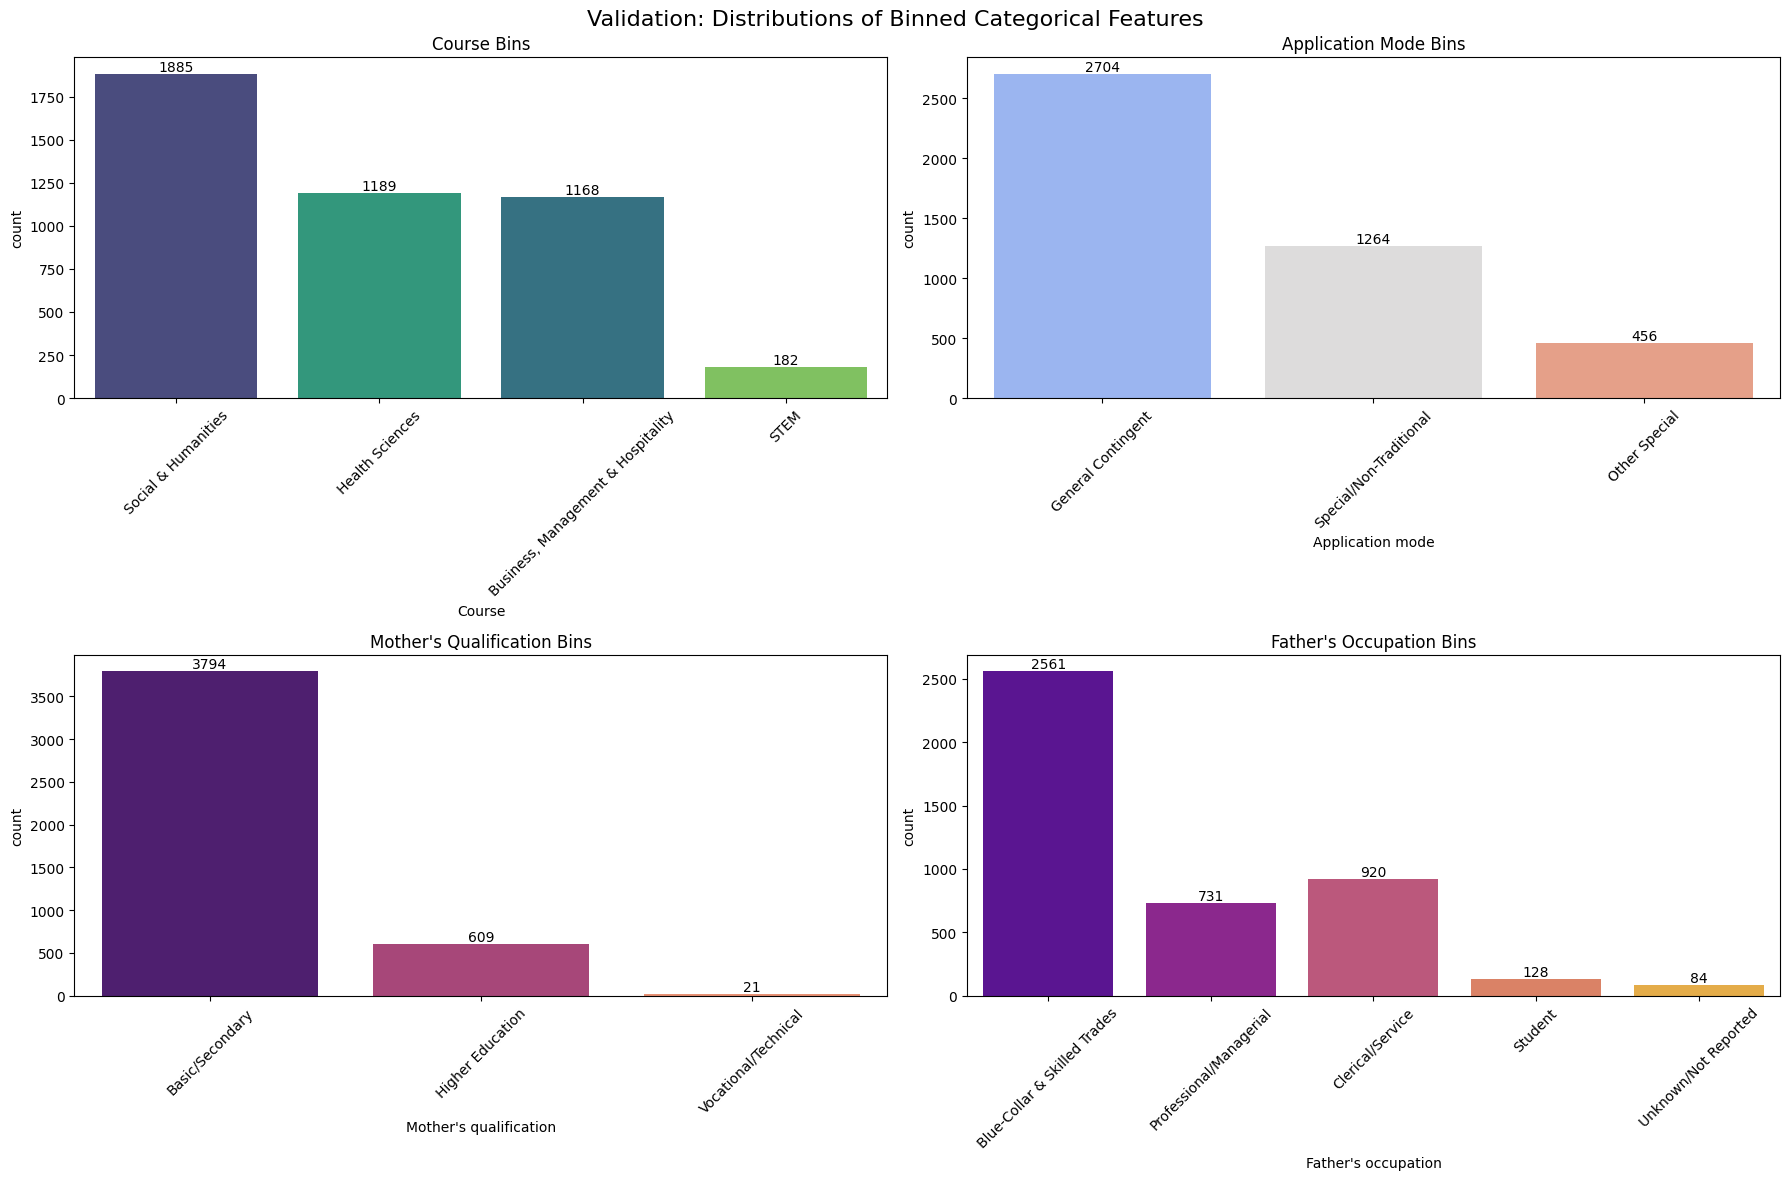

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the 4 most important binned features to see their new shapes
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Validation: Distributions of Binned Categorical Features', fontsize=16)

# Course Bins
sns.countplot(x='Course', data=df, ax=axes[0, 0], palette='viridis', order=df['Course'].value_counts().index, hue='Course', legend=False)
axes[0, 0].set_title('Course Bins')
axes[0, 0].tick_params(axis='x', rotation=45)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.0f', fontsize=10)

# Application Mode Bins
sns.countplot(x='Application mode', data=df, ax=axes[0, 1], palette='coolwarm', hue='Application mode', legend=False)
axes[0, 1].set_title('Application Mode Bins')
axes[0, 1].tick_params(axis='x', rotation=45)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.0f', fontsize=10)

# Mother's Qualification Bins
sns.countplot(x="Mother's qualification", data=df, ax=axes[1, 0], palette='magma', hue="Mother's qualification", legend=False)
axes[1, 0].set_title("Mother's Qualification Bins")
axes[1, 0].tick_params(axis='x', rotation=45)
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.0f', fontsize=10)

# Father's Occupation Bins
sns.countplot(x="Father's occupation", data=df, ax=axes[1, 1], palette='plasma', hue="Father's occupation", legend=False)
axes[1, 1].set_title("Father's Occupation Bins")
axes[1, 1].tick_params(axis='x', rotation=45)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.0f', fontsize=10)

plt.tight_layout()
plt.show()

## **Step 5: Feature engineering**

**1. Is_Mature_Student (Binary)**

Logic: 1 if Age at enrollment > 23, else 0.

Why: The EDA showed age is a massive negative predictor. Binning it helps the model isolate the "non-traditional" student risk group.

**2. First_Generation_Student (Binary)**

Logic: 1 if both Mother's qualification AND Father's qualification are in the "Basic/Secondary" bucket, else 0.

Why: Captures socioeconomic background. First-gen students often lack academic safety nets.

**3. Financial_Risk_Flag (Binary)**

Logic: 1 if Debtor == 'Yes' OR Tuition fees up to date == 'No', else 0.

Why: Combines two financial stress indicators into one powerful "at-risk" signal.

**4. Pass_Rate_1st_Sem (Numerical)**

Logic: Curricular units 1st sem (approved) / Curricular units 1st sem (enrolled). (Handle division by zero by filling with 0).

Why: A student who enrolls in 10 and passes 10 (100%) is fundamentally different from one who enrolls in 20 and passes 5 (25%). The raw numbers hide this ratio.

**5. Pass_Rate_2nd_Sem (Numerical)**

Logic: Same as above, but for the 2nd semester.

**6. Evaluation_Load_Ratio_1st_Sem (Numerical)**

Logic: Curricular units 1st sem (evaluations) / Curricular units 1st sem (enrolled).

Why: Measures How many assessment events did the student undergo per enrolled course.

**7. Evaluation_Load_Ratio_2nd_Sem (Numerical)**

Logic: Same as above, but for the 2nd semester.


In [ ]:
# 1. Is_Mature_Student
df['Is_Mature_Student'] = (df['Age at enrollment'] > 23).astype(int)

# 2. First_Generation_Student
df['First_Generation_Student'] = ((df["Mother's qualification"] == 'Basic/Secondary') & (df["Father's qualification"] == 'Basic/Secondary')).astype(int)

# 3. Financial_Risk_Flag
df['Financial_Risk_Flag'] = ((df['Debtor'] == 'Yes') | (df['Tuition fees up to date'] == 'No')).astype(int)

# 4, 5, 6, 7. Pass Rates and Engagement (Handling division by zero safely)
# If enrolled is 0, we replace it with 1 temporarily to avoid division by zero error. 0/1 = 0.
df['Pass_Rate_1st_Sem'] = df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'].replace(0, 1)
df['Pass_Rate_2nd_Sem'] = df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'].replace(0, 1)
df['Evaluation_Load_Ratio_1st_Sem'] = df['Curricular units 1st sem (evaluations)'] / df['Curricular units 1st sem (enrolled)'].replace(0, 1)
df['Evaluation_Load_Ratio_2nd_Sem'] = df['Curricular units 2nd sem (evaluations)'] / df['Curricular units 2nd sem (enrolled)'].replace(0, 1)

print("✅ Step 5: Feature Engineering complete.")

✅ Step 5: Feature Engineering complete.


In [ ]:
## --- Step 5.1: Feature Engineering Evaluation ---

print("🔍 Running Feature Engineering Validation Hooks...\n")
validation_passed = True

# 1. Check Binary Flags (Values should strictly be 0 or 1)
binary_features = ['Is_Mature_Student', 'First_Generation_Student', 'Financial_Risk_Flag']
for col in binary_features:
    if col in df.columns:
        unique_vals = set(df[col].dropna().unique())
        if not unique_vals.issubset({0, 1}):
            print(f"❌ FAILED: {col} contains unexpected values: {unique_vals} (Expected only 0 and 1)")
            validation_passed = False
        else:
            print(f"✅ PASSED: {col} successfully localized to binary [0, 1].")
    else:
        print(f"❌ FAILED: Column '{col}' is missing entirely.")
        validation_passed = False

# 2. Check Rates for Nulls, Infinities, and Logical Boundaries
rate_features = ['Pass_Rate_1st_Sem', 'Pass_Rate_2nd_Sem', 'Evaluation_Load_Ratio_1st_Sem', 'Evaluation_Load_Ratio_2nd_Sem']
for col in rate_features:
    if col in df.columns:
        # Check for NaN or Inf values
        has_nan = df[col].isna().any()
        has_inf = (df[col] == float('inf')).any() or (df[col] == float('-inf')).any()

        # Check if pass rates exceed 1.0 (Engagement rates can technically be > 1 if evaluations > enrolled)
        exceeds_bounds = False
        if 'Pass_Rate' in col:
            exceeds_bounds = (df[col] > 1.0).any()

        if has_nan or has_inf or exceeds_bounds:
            print(f"❌ FAILED: {col} has math anomalies (NaNs: {has_nan}, Infs: {has_inf}, Exceeds 1.0 boundary: {exceeds_bounds})")
            validation_passed = False
        else:
            print(f"✅ PASSED: {col} looks mathematically sound.")
    else:
        print(f"❌ FAILED: Column '{col}' is missing entirely.")
        validation_passed = False

# --- Final Verdict ---
print("\n" + "="*40)
if validation_passed:
    print("🎉 ALL CHECKS PASSED: The features are clean, safe, and ready for modeling!")
else:
    print("⚠️ WARNING: Some validation checks failed. Review the errors listed above.")
print("="*40)

# Quick look at a sample of the results
print("\n Preview of Engineered Features:")
display_cols = binary_features + rate_features
print(df[display_cols].head())

🔍 Running Feature Engineering Validation Hooks...

✅ PASSED: Is_Mature_Student successfully localized to binary [0, 1].
✅ PASSED: First_Generation_Student successfully localized to binary [0, 1].
✅ PASSED: Financial_Risk_Flag successfully localized to binary [0, 1].
✅ PASSED: Pass_Rate_1st_Sem looks mathematically sound.
✅ PASSED: Pass_Rate_2nd_Sem looks mathematically sound.
✅ PASSED: Evaluation_Load_Ratio_1st_Sem looks mathematically sound.
✅ PASSED: Evaluation_Load_Ratio_2nd_Sem looks mathematically sound.

🎉 ALL CHECKS PASSED: The features are clean, safe, and ready for modeling!

 Preview of Engineered Features:
   Is_Mature_Student  First_Generation_Student  Financial_Risk_Flag  \
0                  0                         1                    0   
1                  0                         0                    1   
2                  0                         1                    1   
3                  0                         1                    0   
4                  1

In [ ]:
all_engineered_features = binary_features + rate_features

for col in all_engineered_features:
    if col in df.columns:
        print(f"{col}:")
        # For binary features, min/max will always be 0/1, but for numerical features
        # we want to see the actual range. Apply formatting for numerical ones.
        if df[col].dtype == 'int64' or df[col].dtype == 'float64':
            print(f"  Min: {df[col].min():.2f}")
            print(f"  Max: {df[col].max():.2f}")
        else:
            # This case should ideally not be hit if all features are numerical/binary
            print(f"  Min: {df[col].min()}")
            print(f"  Max: {df[col].max()}")
        print()

Is_Mature_Student:
  Min: 0.00
  Max: 1.00

First_Generation_Student:
  Min: 0.00
  Max: 1.00

Financial_Risk_Flag:
  Min: 0.00
  Max: 1.00

Pass_Rate_1st_Sem:
  Min: 0.00
  Max: 1.00

Pass_Rate_2nd_Sem:
  Min: 0.00
  Max: 1.00

Evaluation_Load_Ratio_1st_Sem:
  Min: 0.00
  Max: 3.50

Evaluation_Load_Ratio_2nd_Sem:
  Min: 0.00
  Max: 3.83



## **Step 6: Scaling numerical features**

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Application order'
]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("✅ Step 6: Scaling complete.")

✅ Step 6: Scaling complete.


## **Step 7: Final encoding**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Convert Target to numbers for the model
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_Encoded'] = df['Target'].map(target_map)

# One-Hot Encode all remaining categorical string columns
df_final = pd.get_dummies(df, columns=['Marital status', 'Gender', 'Daytime/evening attendance', 'Course',
                                       'Application mode', 'Previous qualification',
                                       "Mother's qualification", "Father's qualification",
                                       "Mother's occupation", "Father's occupation",
                                       'Displaced', 'Debtor', 'Tuition fees up to date',
                                       'Scholarship holder', 'International'],
                                       drop_first=True)

# Drop the original string Target column, keep the encoded one
df_final.drop(columns=['Target'], inplace=True)

print(f"✅ Step 7: Final Encoding complete. Final Shape: {df_final.shape}")
print("🚀 The dataset is now 100% ready for Machine Learning!")

# Save the clean dataset
df_final.to_csv('/content/drive/MyDrive/std_dropout_prediction_project/Cleaned_Dataset_For_Modeling.csv', index=False)

✅ Step 7: Final Encoding complete. Final Shape: (4424, 51)
🚀 The dataset is now 100% ready for Machine Learning!


## **Creating a Feature Dictionary for interpretability**

In [ ]:
feature_dictionary = {
    # Original Numerical Features (Scaled)
    'Application order': 'Application order (scaled)',
    'Previous qualification (grade)': 'Previous qualification grade (scaled)',
    'Admission grade': 'Admission grade (scaled)',
    'Age at enrollment': 'Age at enrollment (scaled)',

    # Curricular Units (Not scaled, raw counts)
    'Curricular units 1st sem (credited)': 'Units credited in 1st semester',
    'Curricular units 1st sem (enrolled)': 'Units enrolled in 1st semester',
    'Curricular units 1st sem (evaluations)': 'Evaluations taken in 1st semester',
    'Curricular units 1st sem (approved)': 'Units approved in 1st semester',
    'Curricular units 1st sem (grade)': 'Average grade in 1st semester',
    'Curricular units 1st sem (without evaluations)': 'Units without evaluations in 1st semester',
    'Curricular units 2nd sem (credited)': 'Units credited in 2nd semester',
    'Curricular units 2nd sem (enrolled)': 'Units enrolled in 2nd semester',
    'Curricular units 2nd sem (evaluations)': 'Evaluations taken in 2nd semester',
    'Curricular units 2nd sem (approved)': 'Units approved in 2nd semester',
    'Curricular units 2nd sem (grade)': 'Average grade in 2nd semester',
    'Curricular units 2nd sem (without evaluations)': 'Units without evaluations in 2nd semester',

    # Engineered Features
    'Is_Mature_Student': '1 if age > 23, else 0',
    'First_Generation_Student': '1 if both parents have Basic/Secondary education, else 0',
    'Financial_Risk_Flag': '1 if debtor OR tuition not up to date, else 0',
    'Pass_Rate_1st_Sem': 'Approved/Enrolled ratio in 1st sem (0-1)',
    'Pass_Rate_2nd_Sem': 'Approved/Enrolled ratio in 2nd sem (0-1)',
    'Evaluation_Load_Ratio_1st_Sem': 'Evaluations/Enrolled ratio in 1st sem',
    'Evaluation_Load_Ratio_2nd_Sem': 'Evaluations/Enrolled ratio in 2nd sem',

    # Target
    'Target_Encoded': '0=Dropout, 1=Enrolled, 2=Graduate',
}

# For One-Hot Encoded columns, explain what TRUE means
one_hot_explanations = {
    'Marital status_Single': 'TRUE if student is Single',
    'Gender_Male': 'TRUE if student is Male (FALSE = Female)',
    'Daytime/evening attendance_Evening': 'TRUE if Evening attendance (FALSE = Daytime)',
    'Course_Health Sciences': 'TRUE if enrolled in Health Sciences course',
    'Course_STEM': 'TRUE if enrolled in STEM course',
    'Course_Social & Humanities': 'TRUE if enrolled in Social & Humanities course',
    # (The dropped category "Business, Management & Hospitality" is the baseline)

    'Application mode_Other Special': 'TRUE if Other Special application mode',
    'Application mode_Special/Non-Traditional': 'TRUE if Special/Non-Traditional mode (Over 23, Transfer, etc.)',
    # (The dropped category "General Contingent" is the baseline)

    'Previous qualification_Higher Education': 'TRUE if previous qual is Higher Education',
    'Previous qualification_Vocational/Technical': 'TRUE if Vocational/Technical',
    # (The dropped category "Basic/Secondary" is the baseline)

    "Mother's qualification_Higher Education": 'TRUE if mother has Higher Education',
    "Mother's qualification_Vocational/Technical": 'TRUE if mother has Vocational/Technical',
    # (The dropped category "Basic/Secondary" is the baseline)

    "Father's qualification_Higher Education": 'TRUE if father has Higher Education',
    "Father's qualification_Vocational/Technical": 'TRUE if father has Vocational/Technical',
    # (The dropped category "Basic/Secondary" is the baseline)

    "Mother's occupation_Clerical/Service": 'TRUE if mother in Clerical/Service job',
    "Mother's occupation_Professional/Managerial": 'TRUE if mother in Professional/Managerial job',
    "Mother's occupation_Student": 'TRUE if mother is Student',
    "Mother's occupation_Unknown/Not Reported": 'TRUE if mother occupation unknown',
    # (The dropped category "Blue-Collar & Skilled Trades" is the baseline)

    "Father's occupation_Clerical/Service": 'TRUE if father in Clerical/Service job',
    "Father's occupation_Professional/Managerial": 'TRUE if father in Professional/Managerial job', # Fixed: Changed closing ' to "
    "Father's occupation_Student": 'TRUE if father is Student',
    "Father's occupation_Unknown/Not Reported": 'TRUE if father occupation unknown',
    # (The dropped category "Blue-Collar & Skilled Trades" is the baseline)

    'Displaced_Yes': 'TRUE if student is displaced',
    'Debtor_Yes': 'TRUE if student is a debtor',
    'Tuition fees up to date_Yes': 'TRUE if tuition fees are up to date',
    'Scholarship holder_Yes': 'TRUE if student has scholarship',
    'International_Yes': 'TRUE if international student',
}

# Merge both dictionaries
feature_dictionary.update(one_hot_explanations)

# Save this dictionary to a CSV for your README and Power BI
feature_df = pd.DataFrame(list(feature_dictionary.items()), columns=['Column_Name', 'Description'])
feature_df.to_csv('/content/drive/MyDrive/std_dropout_prediction_project/Feature_Dictionary.csv', index=False)

print("✅ Feature Dictionary created and saved!")
print("\n--- Sample of Dictionary ---")
print(feature_df.head(15))

✅ Feature Dictionary created and saved!

--- Sample of Dictionary ---
                                       Column_Name  \
0                                Application order   
1                   Previous qualification (grade)   
2                                  Admission grade   
3                                Age at enrollment   
4              Curricular units 1st sem (credited)   
5              Curricular units 1st sem (enrolled)   
6           Curricular units 1st sem (evaluations)   
7              Curricular units 1st sem (approved)   
8                 Curricular units 1st sem (grade)   
9   Curricular units 1st sem (without evaluations)   
10             Curricular units 2nd sem (credited)   
11             Curricular units 2nd sem (enrolled)   
12          Curricular units 2nd sem (evaluations)   
13             Curricular units 2nd sem (approved)   
14                Curricular units 2nd sem (grade)   

                                  Description  
0                

## **Creating a human-readable dataset for Power BI / EDA**

This dataset contains all the cleaned, binned, engineered, and scaled features, but retains the original string values for categorical columns (before one-hot encoding) and the 'Target' column. This makes it ideal for exploratory data analysis or use in tools like Power BI.

In [ ]:
import pandas as pd
import numpy as np # Adding this too, as it might be used by pandas internally or for potential future use related to numerical operations

# Reload raw data to create a new DataFrame for this specific output
df_human_readable = pd.read_csv('/content/drive/MyDrive/std_dropout_prediction_project/Predict_Students_Dropout_and_Academic_Success.csv', sep=';')

# --- Apply Step 2: Decoding Data ---
# Clean column names
df_human_readable.columns = df_human_readable.columns.str.replace(r'\xa0', ' ', regex=True).str.strip()
df_human_readable.rename(columns={'Nacionality': 'Nationality'}, inplace=True)

# Re-define mappings (taken from cell UAPwrsjnFDxt)
marital_map = {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'}
gender_map = {1: 'Male', 0: 'Female'}
attendance_map = {1: 'Daytime', 0: 'Evening'}
yes_no_map = {1: 'Yes', 0: 'No'}
course_map = {
    33: 'Biofuel Production',
    171: 'Animation & Multimedia',
    8014: 'Social Service (Eve)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing',
    9773: 'Journalism',
    9853: 'Basic Education',
    9991: 'Management (Eve)'
}
nationality_map = {
    1: 'Portuguese',
    2: 'German',
    6: 'Spanish',
    11: 'Italian',
    13: 'Dutch',
    14: 'English',
    17: 'Lithuanian',
    21: 'Angolan',
    22: 'Cape Verdean',
    24: 'Guinean',
    25: 'Mozambican',
    26: 'Santomean',
    32: 'Turkish',
    41: 'Brazilian',
    62: 'Romanian',
    100: 'Moldova',
    101: 'Mexican',
    103: 'Ukrainian',
    105: 'Russian',
    108: 'Cuban',
    109: 'Colombian'
}
application_mode_map = {
    1: '1st phase - general contingent',
    2: 'Ordinance No. 612/93',
    5: '1st phase - special contingent (Azores Island)',
    7: 'Holders of other higher courses',
    10: 'Ordinance No. 854-B/99',
    15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)',
    17: '2nd phase - general contingent',
    18: '3rd phase - general contingent',
    26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
    27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
    39: 'Over 23 years old',
    42: 'Transfer',
    43: 'Change of course',
    44: 'Technological specialization diploma holders',
    51: 'Change of institution/course',
    53: 'Short cycle diploma holders',
    57: 'Change of institution/course (International)'
}
prev_qualification_map = {
    1: 'Secondary education',
    2: "Higher education - bachelor's degree",
    3: 'Higher education - degree',
    4: "Higher education - master's",
    5: 'Higher education - doctorate',
    6: 'Frequency of higher education',
    9: '12th year of schooling - not completed',
    10: '11th year of schooling - not completed',
    12: 'Other - 11th year of schooling',
    14: '10th year of schooling',
    15: '10th year of schooling - not completed',
    19: 'Basic education 3rd cycle (9th/10th/11th year)',
    38: 'Basic education 2nd cycle (6th/7th/8th year)',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    42: 'Professional higher technical course',
    43: 'Higher education - master (2nd cycle)'
}
parent_qualification_map = {
    1: 'Secondary Education - 12th Year',
    2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree',
    4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate',
    6: 'Frequency of Higher Education',
    9: '12th Year - Not Completed',
    10: '11th Year - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year',
    13: '2nd year complementary high school',
    14: '10th Year',
    18: 'General commerce course',
    19: 'Basic Education 3rd Cycle',
    20: 'Complementary High School Course',
    22: 'Technical-professional course',
    25: 'Complementary High School - not concluded',
    26: '7th year of schooling',
    27: '2nd cycle of general high school',
    29: '9th Year - Not Completed',
    30: '8th year of schooling',
    31: 'General Course of Administration and Commerce',
    33: 'Supplementary Accounting and Administration',
    34: 'Unknown',
    35: "Can't read or write",
    36: 'Can read without 4th year',
    37: 'Basic education 1st cycle (4th/5th year)',
    38: 'Basic Education 2nd Cycle',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course',
    42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)',
    44: 'Higher Education - Doctorate (3rd cycle)'
}
mother_occupation_map = {
    0: 'Student',
    1: 'Legislative/Executive Directors & Managers',
    2: 'Intellectual/Scientific Specialists',
    3: 'Intermediate Level Technicians',
    4: 'Administrative staff',
    5: 'Personal Services, Security and Sellers',
    6: 'Farmers and Skilled Agriculture/Forestry',
    7: 'Skilled Industry/Construction Workers',
    8: 'Machine Operators and Assembly Workers',
    9: 'Unskilled Workers',
    10: 'Armed Forces Professions',
    90: 'Other Situation',
    122: 'Health professionals',
    123: 'Teachers',
    125: 'ICT Specialists',
    131: 'Intermediate science/engineering technicians',
    132: 'Intermediate health technicians',
    134: 'Intermediate legal/social/sports technicians',
    141: 'Office workers and secretaries',
    143: 'Data/accounting/financial operators',
    144: 'Other administrative support staff',
    151: 'Personal service workers',
    152: 'Sellers',
    153: 'Personal care workers',
    171: 'Skilled construction workers',
    173: 'Skilled printing/jewelers/artisans',
    175: 'Food processing/woodworking/clothing workers',
    191: 'Cleaning workers',
    192: 'Unskilled agriculture/forestry workers',
    193: 'Unskilled extractive/construction/transport',
    194: 'Meal preparation assistants'
}
father_occupation_map = mother_occupation_map.copy()
father_occupation_map.update({
    101: 'Armed Forces Officers',
    102: 'Armed Forces Sergeants',
    103: 'Other Armed Forces personnel',
    112: 'Directors of administrative/commercial services',
    114: 'Hotel/catering/trade directors',
    121: 'Physical sciences/math/engineering specialists',
    124: 'Finance/accounting/PR specialists',
    135: 'ICT technicians',
    154: 'Protection and security services personnel',
    161: 'Market-oriented farmers/agricultural workers',
    163: 'Subsistence farmers/fishermen/hunters',
    172: 'Skilled metallurgy/metalworking workers',
    174: 'Skilled electricity/electronics workers',
    181: 'Fixed plant and machine operators',
    182: 'Assembly workers',
    183: 'Vehicle drivers and mobile equipment operators',
    195: 'Street vendors and service providers'
})

# Apply mappings
df_human_readable['Marital status'] = df_human_readable['Marital status'].map(marital_map)
df_human_readable['Gender'] = df_human_readable['Gender'].map(gender_map)
df_human_readable['Daytime/evening attendance'] = df_human_readable['Daytime/evening attendance'].map(attendance_map)
binary_cols = ['Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'International']
for col in binary_cols: df_human_readable[col] = df_human_readable[col].map(yes_no_map)
df_human_readable['Course'] = df_human_readable['Course'].map(course_map)
df_human_readable['Nationality'] = df_human_readable['Nationality'].map(nationality_map)
df_human_readable['Application mode'] = df_human_readable['Application mode'].map(application_mode_map).fillna('Unknown')
df_human_readable['Previous qualification'] = df_human_readable['Previous qualification'].map(prev_qualification_map).fillna('Unknown')
df_human_readable["Mother's qualification"] = df_human_readable["Mother's qualification"].map(parent_qualification_map).fillna('Unknown')
df_human_readable["Father's qualification"] = df_human_readable["Father's qualification"].map(parent_qualification_map).fillna('Unknown')
df_human_readable["Mother's occupation"] = df_human_readable["Mother's occupation"].map(mother_occupation_map).fillna('Unknown')
df_human_readable["Father's occupation"] = df_human_readable["Father's occupation"].map(father_occupation_map).fillna('Unknown')

# --- Apply Step 3: Dropping Columns (general + specific unwanted columns for dashboard) ---
cols_to_drop_general = ['Educational special needs', 'Nationality', 'Unemployment rate', 'Inflation rate', 'GDP']
cols_to_drop_grades_only = ['Previous qualification (grade)', 'Admission grade'] # These were identified as scaled and should be dropped for dashboard
all_cols_to_drop = list(set(cols_to_drop_general + cols_to_drop_grades_only))
df_human_readable.drop(columns=all_cols_to_drop, inplace=True)

# --- Apply Step 4: Binning High Cardinality Categoricals ---
# Marital Status
df_human_readable['Marital status'] = df_human_readable['Marital status'].apply(lambda x: 'Single' if x == 'Single' else 'Not Single')

# Application Mode
def bin_app_mode(mode):
    if 'general contingent' in str(mode): return 'General Contingent'
    elif 'Over 23' in str(mode) or 'Transfer' in str(mode) or 'International' in str(mode) or 'Change' in str(mode): return 'Special/Non-Traditional'
    else: return 'Other Special'
df_human_readable['Application mode'] = df_human_readable['Application mode'].apply(bin_app_mode)

# Course
def bin_course(course):
    if course in ['Nursing', 'Oral Hygiene', 'Veterinary Nursing']:
        return 'Health Sciences'
    elif course in ['Informatics Eng.', 'Biofuel Production']:
        return 'STEM'
    elif course in ['Management', 'Management (Eve)', 'Advertising & Marketing', 'Tourism']:
        return 'Business, Management & Hospitality'
    else:
        return 'Social & Humanities'
df_human_readable['Course'] = df_human_readable['Course'].apply(bin_course)

# Qualifications (Parents & Previous)
def bin_qual(qual):
    if qual in ['Unknown', "Can't read or write", 'Can read without 4th year', 'Basic education 1st cycle (4th/5th year)', 'Basic Education 2nd Cycle', 'Basic education 2nd cycle (6th/7th/8th year)', 'Basic education 3rd cycle (9th/10th/11th year)', 'Basic Education 3rd Cycle', '7th Year (Old)', '7th year of schooling', '8th year of schooling', '9th Year - Not Completed', '10th Year', '11th Year - Not Completed', '12th Year - Not Completed', 'Secondary Education - 12th Year', 'Secondary education', 'Other - 11th Year', '12th year of schooling - not completed', '11th year of schooling - not completed', '10th year of schooling - not completed', '10th year of schooling', '12th Year of Schooling or Eq.']:
        return 'Basic/Secondary'
    elif 'Higher Education' in str(qual) or 'bachelor' in str(qual) or 'master' in str(qual) or 'doctorate' in str(qual) or 'degree' in str(qual):
        return 'Higher Education'
    else:
        return 'Vocational/Technical'

df_human_readable['Previous qualification'] = df_human_readable['Previous qualification'].apply(bin_qual)
df_human_readable["Mother's qualification"] = df_human_readable["Mother's qualification"].apply(bin_qual)
df_human_readable["Father's qualification"] = df_human_readable["Father's qualification"].apply(bin_qual)

# Occupations (Mother & Father)
def bin_occupation(occupation):
    professional_managerial = [
        'Legislative/Executive Directors & Managers', 'Intellectual/Scientific Specialists',
        'Health professionals', 'Teachers', 'ICT Specialists',
        'Intermediate science/engineering technicians', 'Intermediate health technicians',
        'Intermediate legal/social/sports technicians',
        'Directors of administrative/commercial services', 'Hotel/catering/trade directors',
        'Physical sciences/math/engineering specialists', 'Finance/accounting/PR specialists',
        'ICT technicians', 'Intermediate Level Technicians'
    ]

    clerical_service = [
        'Administrative staff', 'Personal Services, Security and Sellers',
        'Office workers and secretaries', 'Data/accounting/financial operators',
        'Other administrative support staff', 'Personal service workers',
        'Sellers', 'Personal care workers', 'Protection and security services personnel',
        'Street vendors and service providers'
    ]

    blue_collar_trades = [
        'Farmers and Skilled Agriculture/Forestry', 'Skilled Industry/Construction Workers',
        'Machine Operators and Assembly Workers', 'Unskilled Workers',
        'Armed Forces Professions', 'Skilled construction workers',
        'Skilled printing/jewelers/artisans', 'Food processing/woodworking/clothing workers',
        'Cleaning workers', 'Unskilled agriculture/forestry workers',
        'Unskilled extractive/construction/transport', 'Meal preparation assistants',
        'Market-oriented farmers/agricultural workers', 'Subsistence farmers/fishermen/hunters',
        'Skilled metallurgy/metalworking workers',
        'Skilled electricity/electronics workers', 'Fixed plant and machine operators',
        'Assembly workers', 'Vehicle drivers and mobile equipment operators', 'Armed Forces Officers',
        'Armed Forces Sergeants', 'Other Armed Forces personnel'
    ]

    if occupation == 'Student':
        return 'Student'
    elif occupation in ['Other Situation', 'Unknown', '(blank)', 'Not Reported']:
        return 'Unknown/Not Reported'
    elif occupation in professional_managerial:
        return 'Professional/Managerial'
    elif occupation in clerical_service:
        return 'Clerical/Service'
    elif occupation in blue_collar_trades:
        return 'Blue-Collar & Skilled Trades'
    else:
        return 'Other/Unspecified'

df_human_readable["Mother's occupation"] = df_human_readable["Mother's occupation"].apply(bin_occupation)
df_human_readable["Father's occupation"] = df_human_readable["Father's occupation"].apply(bin_occupation)

# --- Apply Step 5: Feature engineering ---
# 1. Is_Mature_Student
df_human_readable['Is_Mature_Student'] = (df_human_readable['Age at enrollment'] > 23).astype(int)

# 2. First_Generation_Student
df_human_readable['First_Generation_Student'] = ((df_human_readable["Mother's qualification"] == 'Basic/Secondary') & (df_human_readable["Father's qualification"] == 'Basic/Secondary')).astype(int)

# 3. Financial_Risk_Flag
df_human_readable['Financial_Risk_Flag'] = ((df_human_readable['Debtor'] == 'Yes') | (df_human_readable['Tuition fees up to date'] == 'No')).astype(int)

# 4, 5, 6, 7. Pass Rates and Engagement (Handling division by zero safely)
df_human_readable['Pass_Rate_1st_Sem'] = df_human_readable['Curricular units 1st sem (approved)'] / df_human_readable['Curricular units 1st sem (enrolled)'].replace(0, 1)
df_human_readable['Pass_Rate_2nd_Sem'] = df_human_readable['Curricular units 2nd sem (approved)'] / df_human_readable['Curricular units 2nd sem (enrolled)'].replace(0, 1)
df_human_readable['Evaluation_Load_Ratio_1st_Sem'] = df_human_readable['Curricular units 1st sem (evaluations)'] / df_human_readable['Curricular units 1st sem (enrolled)'].replace(0, 1)
df_human_readable['Evaluation_Load_Ratio_2nd_Sem'] = df_human_readable['Curricular units 2nd sem (evaluations)'] / df_human_readable['Curricular units 2nd sem (enrolled)'].replace(0, 1)

# --- NO SCALING for Dashboard-Ready Data --- 
# The original numerical features like 'Age at enrollment' and 'Application order' 
# should remain unscaled for human-readability in Power BI.

# --- Save the human-readable dataset ---
output_path = '/content/drive/MyDrive/std_dropout_prediction_project/Dashboard_Ready_Data.csv'
df_human_readable.to_csv(output_path, index=False)

print(f"✅ Dashboard-ready dataset saved to: {output_path}")
print(f"Shape of dashboard-ready dataset: {df_human_readable.shape}")
print("First 5 rows of the dashboard-ready dataset (numerical columns are unscaled and problematic scaled columns are dropped):")
display(df_human_readable.head())

✅ Human-readable dataset saved to: /content/drive/MyDrive/std_dropout_prediction_project/Human_Readable_Dataset_Before_OneHotEncoding.csv
Shape of human-readable dataset: (4424, 39)
First 5 rows of the human-readable dataset:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Target,Is_Mature_Student,First_Generation_Student,Financial_Risk_Flag,Pass_Rate_1st_Sem,Pass_Rate_2nd_Sem,Evaluation_Load_Ratio_1st_Sem,Evaluation_Load_Ratio_2nd_Sem
0,Single,General Contingent,2.490896,Social & Humanities,Daytime,Basic/Secondary,-0.804841,Basic/Secondary,Basic/Secondary,Clerical/Service,...,0.000000,0,Dropout,0,1,0,0.000000,0.000000,0.000000,0.000000
1,Single,Special/Non-Traditional,-0.554068,"Business, Management & Hospitality",Daytime,Basic/Secondary,2.076819,Basic/Secondary,Higher Education,Professional/Managerial,...,13.666667,0,Graduate,0,0,1,1.000000,1.000000,1.000000,1.000000
2,Single,General Contingent,2.490896,Social & Humanities,Daytime,Basic/Secondary,-0.804841,Basic/Secondary,Basic/Secondary,Blue-Collar & Skilled Trades,...,0.000000,0,Dropout,0,1,1,0.000000,0.000000,0.000000,0.000000
3,Single,General Contingent,0.207173,Social & Humanities,Daytime,Basic/Secondary,-0.804841,Basic/Secondary,Basic/Secondary,Clerical/Service,...,12.400000,0,Graduate,0,1,0,1.000000,0.833333,1.333333,1.666667
4,Not Single,Special/Non-Traditional,-0.554068,Social & Humanities,Evening,Basic/Secondary,-2.473171,Basic/Secondary,Basic/Secondary,Blue-Collar & Skilled Trades,...,13.000000,0,Graduate,1,1,0,0.833333,1.000000,1.500000,1.000000
